<a href="https://colab.research.google.com/github/keerthisingh-analyst/chatgpt_review_analysis/blob/main/ChatGpt_Review_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from textblob import TextBlob
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')
#

In [ ]:
Link = "/content/chatgpt_reviews.xlsx"
df = pd.read_excel(Link)
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()


,review_id,review,ratings,review_date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   review_id    196727 non-null  object        
 1   review       196721 non-null  object        
 2   ratings      196727 non-null  int64         
 3   review_date  196727 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 6.0+ MB


In [ ]:
df.describe()

,ratings,review_date
count,196727.000000,196727
mean,4.503535,2024-03-25 22:03:05.784020736
min,1.000000,2023-07-25 15:01:35
25%,5.000000,2024-01-06 09:47:07
50%,5.000000,2024-04-22 20:53:30
75%,5.000000,2024-06-24 16:43:04.500000
max,5.000000,2024-08-23 19:30:05
std,1.083004,NaN


In [ ]:
df.isnull().sum()

,0
review_id,0
review,6
ratings,0
review_date,0


In [ ]:
df['review'] = df['review'].fillna(" ")
df.isnull().sum()

,0
review_id,0
review,0
ratings,0
review_date,0


**Sentiment Analysis**

In [ ]:
def get_sentiment_polarity(text):
    if pd.isna(text) or text == '':
        return 0

    blob = TextBlob(str(text))
    return blob.sentiment.polarity

df['sentiment_polarity'] = df['review'].apply(get_sentiment_polarity)

df.head(10)

,review_id,review,ratings,review_date,sentiment_polarity
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,0.7000
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,0.7000
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,0.6000
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,0.6000
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,0.4125
5,9cdc3f78-15cd-4e9d-9287-31bc5af496c4,so nice app,5,2024-08-23 19:18:35,0.6000
6,3c26ee92-4d72-45ee-9242-caab930903ca,"just love this app, or guy",4,2024-08-23 19:14:40,0.5000
7,f293ed19-688a-42e2-8282-ddd077771a94,great app,1,2024-08-23 19:12:00,0.8000
8,99af016c-6db2-4f24-9952-cb3bece40be8,Very impressive,5,2024-08-23 19:11:46,1.0000
9,27dd6ea5-ada3-4795-a297-6faa7d4b6ba2,helps with coding a lot this ai is great for e...,5,2024-08-23 19:11:09,0.8000


In [ ]:
def get_sentiment_category(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_polarity'].apply(get_sentiment_category)

df.head()

,review_id,review,ratings,review_date,sentiment_polarity,sentiment_category
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,0.7000,Positive
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,0.7000,Positive
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,0.6000,Positive
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,0.6000,Positive
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,0.4125,Positive


In [ ]:
def get_sentiment_subjectivity(text):
    if pd.isna(text) or text == '':
        return 0

    blob = TextBlob(str(text))
    return blob.sentiment.subjectivity

df['sentiment_subjectivity'] = df['review'].apply(get_sentiment_subjectivity)

df.head()

,review_id,review,ratings,review_date,sentiment_polarity,sentiment_category,sentiment_subjectivity
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,0.7000,Positive,0.600000
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,0.7000,Positive,0.600000
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,0.6000,Positive,1.000000
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,0.6000,Positive,1.000000
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,0.4125,Positive,0.542949


In [ ]:
df['sentiment_category'].value_counts()

,count
sentiment_category,
Positive,145551
Neutral,44870
Negative,6306


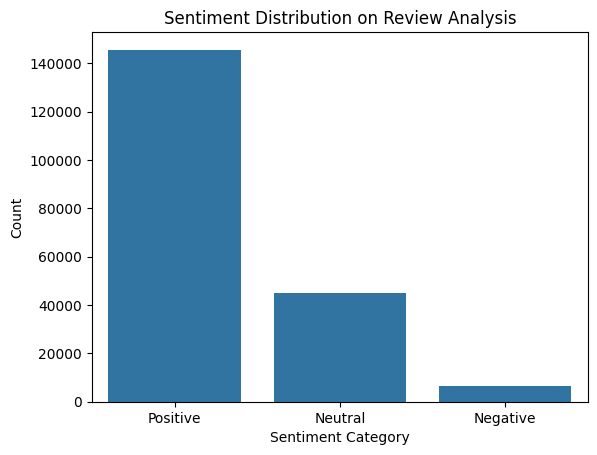

In [ ]:
sentiment_category = df['sentiment_category'].value_counts()

sns.barplot(
    x=sentiment_category.index,
    y=sentiment_category.values
)

plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.title('Sentiment Distribution on Review Analysis')
plt.show()

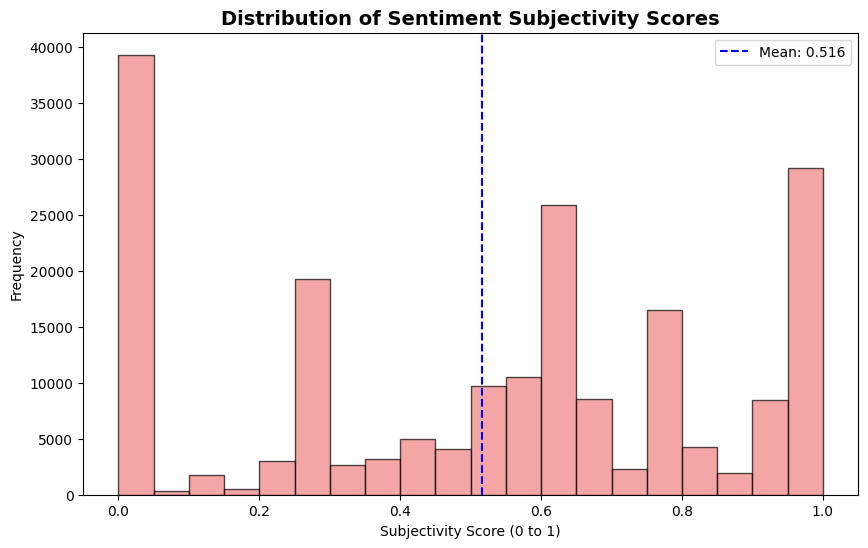

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df['sentiment_subjectivity'],
    bins=20,
    alpha=0.7,
    color='lightcoral',
    edgecolor='black'
)

plt.axvline(
    df['sentiment_subjectivity'].mean(),
    color='blue',
    linestyle='--',
    label=f"Mean: {df['sentiment_subjectivity'].mean():.3f}"
)

plt.title(
    "Distribution of Sentiment Subjectivity Scores",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Subjectivity Score (0 to 1)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

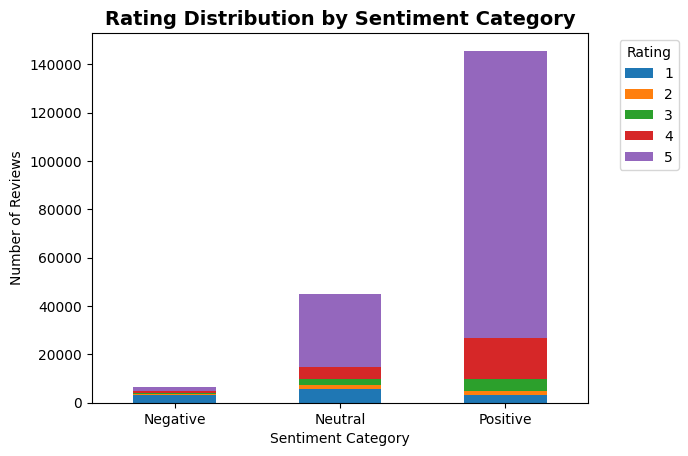

In [ ]:
# # 3. Rating Distribution by Sentiment Category
sentiment_rating = df.groupby(['sentiment_category', 'ratings']).size().unstack(fill_value=0)
sentiment_rating.plot(kind='bar', stacked=True)
plt.title('Rating Distribution by Sentiment Category', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

**Analyzing Positive Features**

In [ ]:
positive_reviews = df[df['sentiment_category'] == 'Positive']['review']

In [ ]:
positive_reviews

,review
0,good
1,good
2,nice app
3,"nice, ig"
4,"this is a great app, the bot is so accurate to..."
...,...
196702,Super App
196704,First download
196711,very goid
196714,first review


Extract Positive Keywords and Phrases

In [ ]:
import re
# Extract positive keywords and phrases

all_text = ' '.join(positive_reviews.astype(str)).lower()

# Clean text
cleaned_text = re.sub(r'[^a-zA-Z\s]', '', all_text)
words = cleaned_text.split()

# Remove all words whose length is < 3
words = [word for word in words if len(word) > 2]

# Get phrases (bigrams and trigrams)
phrases = []
for i in range(len(words) - 1):
    if len(words[i]) > 2 and len(words[i+1]) > 2:  # Skip short words
        phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
    if all(len(word) > 2 for word in words[i:i+3]):  # Skip short words
        phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

pos_phrases = phrase_freq.most_common(10)

In [ ]:
pos_phrases

[('this app', 10262),
 ('very good', 9334),
 ('the best', 6790),
 ('good app', 5799),
 ('very helpful', 5452),
 ('best app', 5407),
 ('app very', 4622),
 ('very useful', 4267),
 ('good good', 3959),
 ('very nice', 3495)]

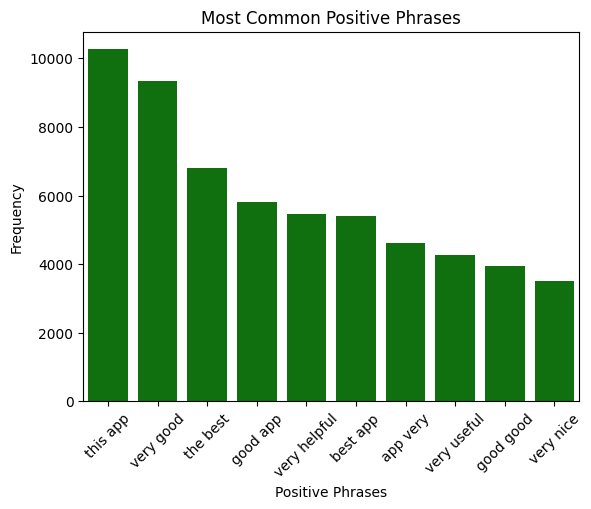

In [ ]:
from ipywidgets.widgets.widget_int import Color
sns.barplot(x=[phrase[0] for phrase in pos_phrases], y=[phrase[1] for phrase in pos_phrases], color='green')
plt.xlabel('Positive Phrases')
plt.ylabel('Frequency')
plt.title('Most Common Positive Phrases')
plt.xticks(rotation=45)
plt.show()


In [ ]:
Negative_reviews = df[df['sentiment_category'] == "Negative"]['review']

In [ ]:
Negative_reviews

,review
10,I am not very happy with this because chatgpt ...
119,not good
134,Too expensive
176,"Correct answer Accuracy 10 %,always provide wr..."
222,"I get a ""something went wrong"" error so I can'..."
...,...
196145,Sucks
196617,random sjsj
196665,Not sure
196672,hands down


In [ ]:
import re
# Extract positive keywords and phrases

all_text = ' '.join(Negative_reviews.astype(str)).lower()

# Clean text
cleaned_text = re.sub(r'[^a-zA-Z\s]', '', all_text)
words = cleaned_text.split()

# Remove all words whose length is < 3
words = [word for word in words if len(word) > 2]

# Get phrases (bigrams and trigrams)
phrases = []
for i in range(len(words) - 1):
    if len(words[i]) > 2 and len(words[i+1]) > 2:  # Skip short words
        phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
    if all(len(word) > 2 for word in words[i:i+3]):  # Skip short words
        phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

neg_phrases = phrase_freq.most_common(10)

In [ ]:
neg_phrases

[('this app', 548),
 ('the app', 402),
 ('very bad', 259),
 ('not good', 171),
 ('chat gpt', 133),
 ('worst app', 129),
 ('bad app', 114),
 ('wrong answer', 108),
 ('its not', 105),
 ('with the', 99)]

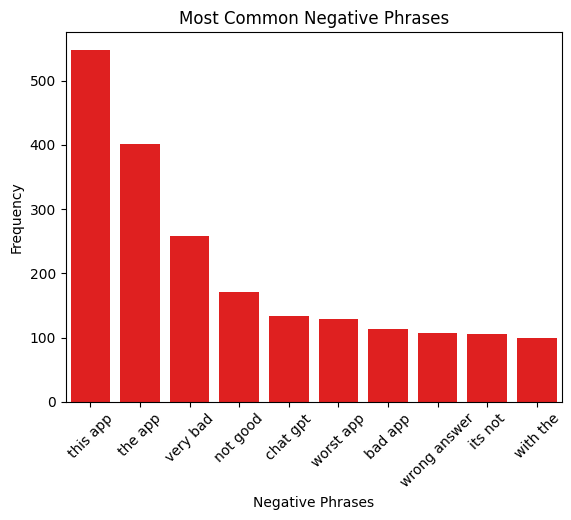

In [ ]:
sns.barplot(x=[phrase[0] for phrase in neg_phrases], y=[phrase[1] for phrase in neg_phrases], color='red')
plt.xlabel('Negative Phrases')
plt.ylabel('Frequency')
plt.title('Most Common Negative Phrases')
plt.xticks(rotation=45)
plt.show()

In [ ]:
neutral_reviews = df[df['sentiment_category'] == "Neutral"]['review']

In [ ]:
neutral_reviews

,review
17,🫶🏻
22,beleza
24,abdul baset
25,2024-08-23 Call function doesn't get language ...
29,👍👍👍👍👍👍👍
...,...
196722,Update 2023
196723,its grear
196724,Funtastic App
196725,hi all


In [ ]:
all_text = ' '.join(neutral_reviews.astype(str)).lower()

# Clean text
cleaned_text = re.sub(r'[^a-zA-Z\s]', '', all_text)
words = cleaned_text.split()

# Remove all words whose length is < 3
words = [word for word in words if len(word) > 2]

# Get phrases (bigrams and trigrams)
phrases = []
for i in range(len(words) - 1):
    if len(words[i]) > 2 and len(words[i+1]) > 2:  # Skip short words
        phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
    if all(len(word) > 2 for word in words[i:i+3]):  # Skip short words
        phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

neu_phrases = phrase_freq.most_common(10)

In [ ]:
neu_phrases

[('this app', 2020),
 ('the app', 1143),
 ('chat gpt', 756),
 ('thank you', 706),
 ('not working', 445),
 ('like this', 368),
 ('for the', 300),
 ('the future', 292),
 ('helpful for', 284),
 ('its not', 271)]

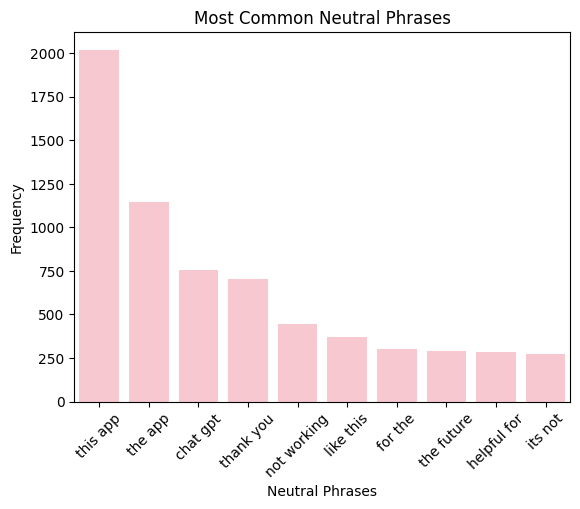

In [ ]:
sns.barplot(x=[phrase[0] for phrase in neu_phrases], y=[phrase[1] for phrase in neu_phrases], color='pink')
plt.xlabel('Neutral Phrases')
plt.ylabel('Frequency')
plt.title('Most Common Neutral Phrases')
plt.xticks(rotation=45)
plt.show()

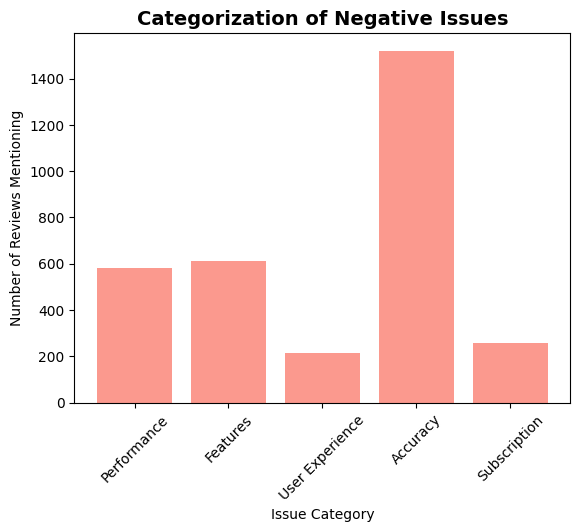

In [ ]:
issue_categories = {
    'Performance': ['slow', 'lag', 'crash', 'freeze', 'glitch', 'bug', 'error'],
    'Features': ['missing', 'lack', 'need', 'want', 'should', 'feature'],
    'User Experience': ['confusing', 'difficult', 'hard', 'complicated', 'interface'],
    'Accuracy': ['wrong', 'incorrect', 'bad', 'poor', 'inaccurate', 'mistake'],
    'Subscription': ['expensive', 'price', 'cost', 'pay', 'subscription', 'money']
}

category_counts = {}
for category, keywords in issue_categories.items():
    count = 0
    for review in Negative_reviews:
        if any(keyword in str(review).lower() for keyword in keywords):
            count += 1
    category_counts[category] = count

categories = list(category_counts.keys())
counts = list(category_counts.values())

plt.bar(categories, counts, color='salmon', alpha=0.8)
plt.title('Categorization of Negative Issues', fontsize=14, fontweight='bold')
plt.xlabel('Issue Category')
plt.ylabel('Number of Reviews Mentioning')
plt.xticks(rotation=45)

plt.show()

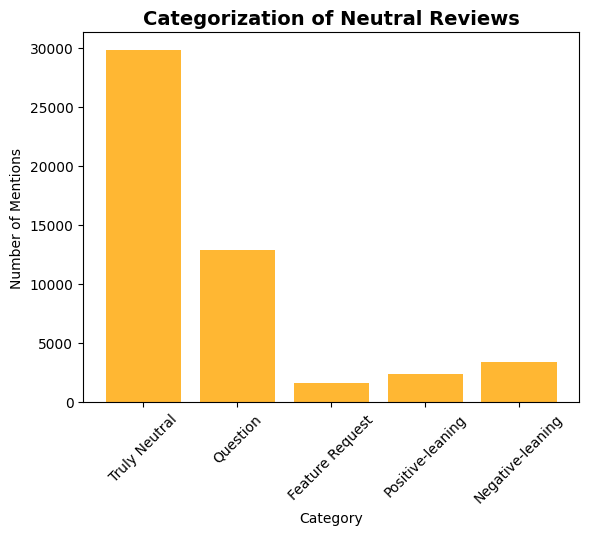

In [ ]:
neutral_texts = neutral_reviews

keyword_map = {
    'Feature Request': ['add', 'include', 'feature', 'option', 'setting', 'would like', 'wish', 'hope'],
    'Question': ['how', 'what', 'why', 'when', 'where', 'can', 'does', 'is', '?'],
    'Positive-leaning': ['good', 'nice', 'ok', 'fine', 'decent', 'works'],
    'Negative-leaning': ['but', 'however', 'issue', 'problem', 'concern', 'could be better']
}

neutral_categories = []

for text in neutral_texts:
    text_lower = str(text).lower()
    categories = []

    for label, keywords in keyword_map.items():
        if any(keyword in text_lower for keyword in keywords):
            categories.append(label)

    if not categories:
        categories.append('Truly Neutral')

    neutral_categories.extend(categories)

# Count categories
category_counts = Counter(neutral_categories)

if category_counts:
    plt.figure()

    categories = list(category_counts.keys())
    counts = list(category_counts.values())

    plt.bar(categories, counts, color='orange', alpha=0.8)
    plt.title('Categorization of Neutral Reviews', fontsize=14, fontweight='bold')
    plt.xlabel('Category')
    plt.ylabel('Number of Mentions')
    plt.xticks(rotation=45)

    plt.show()

**Review Evolution Over Time**

In [ ]:
df['review_month'] = df['review_date'].dt.to_period('M')
df['review_quater'] = df['review_date'].dt.to_period('Q')


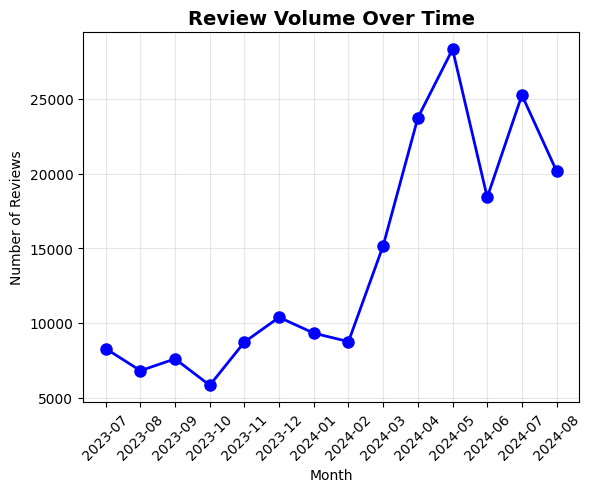

In [ ]:
monthly_counts = df.groupby('review_month').size()
plt.plot(monthly_counts.index.astype(str), monthly_counts.values,
         marker='o', linewidth=2, markersize=8, color='blue')

plt.title('Review Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

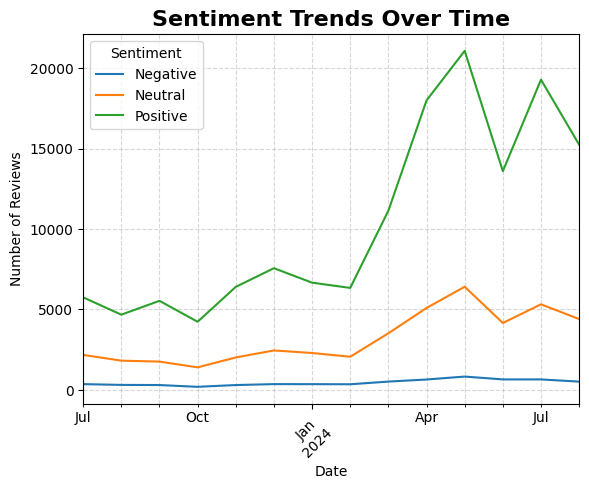

In [ ]:
df['review_date'] = pd.to_datetime(df['review_date'])

sentiment_over_time = df.groupby([df['review_date'].dt.to_period('M'), 'sentiment_category'])\
                        .size().unstack(fill_value=0)

sentiment_over_time.index = sentiment_over_time.index.to_timestamp()
sentiment_over_time.plot()

plt.title('Sentiment Trends Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Sentiment')

plt.show()

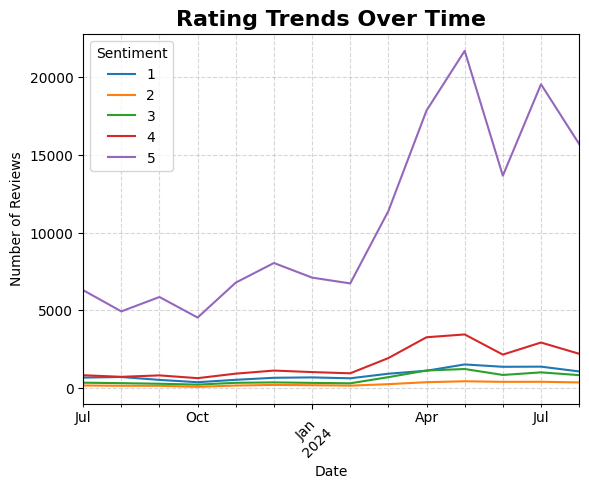

In [ ]:
df['review_date'] = pd.to_datetime(df['review_date'])

sentiment_over_time = df.groupby([df['review_date'].dt.to_period('M'), 'ratings'])\
                        .size().unstack(fill_value=0)

sentiment_over_time.index = sentiment_over_time.index.to_timestamp()
sentiment_over_time.plot()

plt.title('Rating Trends Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Sentiment')

plt.show()

In [ ]:
import os

# Ensure the current working directory is /content/
os.chdir('/content/')

# Create a .gitignore file to exclude unnecessary files
!echo -e "/.config/\n/sample_data/\n*.xlsx\n*.ipynb_checkpoints/\n.git/" > .gitignore

# Initialize Git repository (harmless if already done)
!git init

# Configure Git user (replace with your details)
# IMPORTANT: Replace "your_email@example.com" and "Your Name" with your GitHub credentials
!git config user.email "your_email@example.com"
!git config user.name "Your Name"

# Add the current notebook and .gitignore to the repository
# IMPORTANT: Please manually save your current notebook as 'chatgpt_review_analysis.ipynb'
# in the /content/ directory BEFORE running this cell.
!git add chatgpt_review_analysis.ipynb .gitignore

# Commit the changes (|| true prevents error if nothing new to commit)
!git commit -m "Initial commit of Colab notebook with .gitignore" || true

# Remove existing remote 'origin' if it exists to avoid 'remote origin already exists' error
!git remote remove origin || true

# Add the GitHub remote origin with your Personal Access Token (PAT) for authentication
# IMPORTANT: Replace <YOUR_GITHUB_TOKEN> with your actual GitHub Personal Access Token.
# To generate a PAT, go to GitHub settings > Developer settings > Personal access tokens.
!git remote add origin https://<YOUR_GITHUB_TOKEN>@github.com/keerthisingh-analyst/chatgpt_review_analysis.git

# Set the branch name to 'main'
!git branch -M main

# Push the changes
!git push -u origin main

Reinitialized existing Git repository in /content/.git/
fatal: pathspec 'chatgpt_review_analysis.ipynb' did not match any files
On branch main
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore

nothing added to commit but untracked files present (use "git add" to track)
error: No such remote: 'origin'
/bin/bash: line 1: YOUR_GITHUB_TOKEN: No such file or directory
fatal: 'origin' does not appear to be a git repository
fatal: Could not read from remote repository.

Please make sure you have the correct access rights
and the repository exists.
